In [ ]:
%pip install numpy

In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
#Load data from csv
#df = pd.read_csv("data/MS_A_C.csv")

In [2]:
words_count = {}
variations = {}
ratio_var = {}

In [3]:
def load_csv_files(directory):
    
    #Load all CSV files in a given directory and return them as a dictionary.
    
    dataframes = {}
    
    # Loop through all the files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(filepath)
            # Add the DataFrame to the dictionary with the filename as the key
            filename = filename.split('.')[0]
            dataframes[filename] = df
    
    return dataframes

In [4]:
directory = './data'  # Path to the directory where the CSVs are stored
dataframes = load_csv_files(directory)

In [14]:
"""
Words count
"""
# Loop on each data frame in each csv
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    #df = df[df['Categories'] != 'Unclassifiable']
    
    # select the name of columns "MS_" but excluding marginal notes "_mg"
    ms_columns = [col for col in df.columns if "MS_" in col and "_mg" not in col]

    words_count[filename] = {}
    words_count[filename]["words_ms_1"] = df[ms_columns[0]].notna().sum() #Number of words in col 1
    words_count[filename]["words_ms_2"] = df[ms_columns[1]].notna().sum() #Number of words in col 2
    words_count[filename]["words_alligned"] = df[df[ms_columns[0]].notna() & df[ms_columns[1]].notna()].shape[0] #number of aligned words
    words_count[filename]["Words_not_alligned"] = df[(df[ms_columns[1]].notna() & df[ms_columns[0]].isna()) | (df[ms_columns[0]].notna() & df[ms_columns[1]].isna())].shape[0] #number of words not aligned
    

    
    variants = df.groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category

    #Calculate the percentage of each category in relation to the number of aligned and non-aligned words
    for variant in variants:
        words_count[filename][variant] = variants[variant]# * 100 / (words_count[filename]["words_alligned"] + words_count[filename]["Words_not_alligned"])

pd.DataFrame.from_dict(words_count).round(1).T.fillna("")

,words_ms_1,words_ms_2,words_alligned,Words_not_alligned,Lexical,Morphological,Plus_Minus,Same,Unclassifiable,Inversion,?,Unclassified
MSS_M_Bmg,219.0,885.0,179.0,746.0,33.0,39.0,1.0,67.0,7.0,,,
MSS_C_D,41.0,50.0,41.0,9.0,3.0,4.0,9.0,17.0,15.0,2.0,,
MSS_A_D,70.0,69.0,69.0,1.0,1.0,7.0,1.0,44.0,17.0,,,
MSS_E_F,114.0,114.0,114.0,0.0,,2.0,,58.0,28.0,,,
MSS_A_C,390.0,422.0,361.0,90.0,69.0,49.0,51.0,233.0,6.0,6.0,,
MSS_BMg_C,6.0,54.0,6.0,48.0,3.0,,,1.0,2.0,,,
MSS_B_F,272.0,258.0,238.0,54.0,23.0,20.0,47.0,145.0,38.0,2.0,1.0,
MSS_B_E,122.0,119.0,118.0,5.0,11.0,6.0,10.0,44.0,24.0,,,2.0
MSS_B_D,242.0,237.0,236.0,7.0,40.0,37.0,15.0,142.0,3.0,4.0,,1.0
MSS_BMg_D,77.0,9.0,1.0,84.0,9.0,10.0,1.0,63.0,1.0,,,


In [6]:
"""
Percentage of variations
"""
# Loop on each data frame in each csv
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']
    
    variations[filename] = {}

    variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
    same = df[df['Categories'] == 'Same'].shape[0]
    ratio = variants * 100 / (variants+same)
    variations[filename]=[ratio]

df = pd.DataFrame.from_dict(variations).round(0).T.sort_index(ascending=True)
df.columns = ["ratio"]
df

,ratio
MSS_A_C,43.0
MSS_A_D,17.0
MSS_BMg_C,75.0
MSS_BMg_D,24.0
MSS_B_11QPsa,81.0
MSS_B_Bmg,81.0
MSS_B_C,35.0
MSS_B_D,41.0
MSS_B_E,40.0
MSS_B_F,39.0


In [7]:
"""
Variation rates on categories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']

    ratio_var[filename] = {}
    
    variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
    total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
    #print(f"{filename} : {variants} - total variants {total_variants}")
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants

pd.DataFrame.from_dict(ratio_var).round(1).T.fillna("").sort_index(ascending=True)

,Lexical,Morphological,Plus_Minus,Inversion,?,Unclassified
MSS_A_C,39.4,28.0,29.1,3.4,,
MSS_A_D,11.1,77.8,11.1,,,
MSS_BMg_C,100.0,,,,,
MSS_BMg_D,45.0,50.0,5.0,,,
MSS_B_11QPsa,41.1,12.5,46.4,,,
MSS_B_Bmg,48.3,33.9,17.0,0.9,,
MSS_B_C,46.7,20.0,20.0,13.3,,
MSS_B_D,41.2,38.1,15.5,4.1,,1.0
MSS_B_E,37.9,20.7,34.5,,,6.9
MSS_B_F,24.7,21.5,50.5,2.2,1.1,


<Axes: >

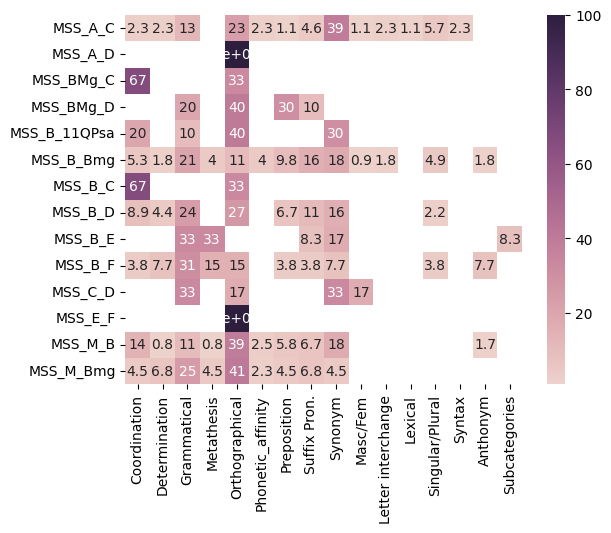

In [13]:
"""
Variation rates on subcategories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']
 
    ratio_var[filename] = {}
    
    variants = df.groupby('Subcategories_1').size().to_dict() # Create a dictionary of the number of item in each category
    total_variants = df.groupby('Subcategories_1').size().sum()
    #print(f"{filename} : {variants} - total variants {total_variants}")
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants

table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
    